In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Anaconda\envs\study_env2\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Anaconda\envs\study_env2\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Anaconda\envs\study_env2\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Anaconda\envs\study_env2\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Anaconda\envs\study_en

In [2]:
def set_seed(seed = 42):
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed = 12
set_seed(seed= seed)

In [3]:
ROOT_DIR = Path.cwd().parent
ROOT_DIR

WindowsPath('D:/Code Module 6/RNN_for_Text_TimeSeries')

In [4]:
DATA_PATH = ROOT_DIR/'data'/'weatherHistory.csv'

In [5]:
df = pd.read_csv(str(DATA_PATH))
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


# Lấy ra các thông tin cơ bản của bộ DL

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 8.8 MB


In [7]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


# Data preprocessing

In [8]:
# kiểm tra DL có Nan
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [9]:
# fill các giá trị Nan băng các giá trị đằng trước
df.ffill(inplace=True)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [10]:
df.drop(columns=['Formatted Date'],inplace=True)

In [11]:
df.head(5)

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


# Encode from text to number

In [12]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
Encoder = OrdinalEncoder()

In [13]:
df[['Summary','Precip Type','Daily Summary']] = Encoder.fit_transform(df[['Summary','Precip Type','Daily Summary']])

In [14]:
df

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,19.0,0.0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,197.0
1,19.0,0.0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,197.0
2,17.0,0.0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,197.0
3,19.0,0.0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,197.0
4,17.0,0.0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,197.0
...,...,...,...,...,...,...,...,...,...,...,...
96448,19.0,0.0,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,170.0
96449,19.0,0.0,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,170.0
96450,19.0,0.0,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,170.0
96451,19.0,0.0,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,170.0


In [15]:
df['target'] = df['Temperature (C)']
df

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,target
0,19.0,0.0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,197.0,9.472222
1,19.0,0.0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,197.0,9.355556
2,17.0,0.0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,197.0,9.377778
3,19.0,0.0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,197.0,8.288889
4,17.0,0.0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,197.0,8.755556
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,19.0,0.0,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,170.0,26.016667
96449,19.0,0.0,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,170.0,24.583333
96450,19.0,0.0,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,170.0,22.038889
96451,19.0,0.0,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,170.0,21.522222


# Xây dựng kiểu dữ liệu TimeSeriesDataSet kế thừa lớp DataSet trong pytorch

In [16]:
# Xây dựng lớp TimeSeriesDataSet kế thừa lớp DataSet trong pytorch
class TimeSeriesDataSet(Dataset):
    def __init__(self, df, split: str = 'train', validation_split = 0.2, test_split = 0.1, normalize: bool = True, num_shift = 5):
        super().__init__()
        self.df = df
        scaler = StandardScaler()
        if split != 'train' and split != 'test' and split != 'valid':
            raise ValueError(f"split unsupport {split}!")
        df_train, df_test = train_test_split(df, test_size=test_split, shuffle=False)
        df_train, df_val = train_test_split(df_train, test_size=validation_split, shuffle=False)
        trainset = df_train.to_numpy()
        testset = df_test.to_numpy()
        valset = df_val.to_numpy()
        X_train = trainset[:,:-1]
        scaler.fit(X_train)
        if split == 'train':
            arrX = scaler.transform(trainset[:,:-1])
            arry = trainset[:,-1]
        elif split == 'test':
            arrX = scaler.transform(testset[:,:-1])
            arry = testset[:,-1]
        else:
            arrX = scaler.transform(valset[:,:-1])
            arry = valset[:,-1]
        self.X, self.y = self.shift_data(arrX, arry, num_shift = num_shift)
    def shift_data(self, arrX, arry, num_shift):
        X =[]
        y = []
        for i in range(len(arrX) - num_shift):
            X.append(arrX[i:i+num_shift])
            y.append(arry[i+num_shift])
        X = np.array(X)
        y = np.array(y).reshape(-1,1)
        return torch.tensor(X), torch.tensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [17]:
TrainDataSet = TimeSeriesDataSet(df= df, split='train')
ValDataSet = TimeSeriesDataSet(df= df, split='valid')
TestDataSet = TimeSeriesDataSet(df= df, split='test')

In [18]:
TrainDataSet[0][0].shape

torch.Size([5, 11])

In [19]:
TrainDataSet[0]

(tensor([[ 0.6935, -0.3836, -0.2337, -0.2973,  0.8064,  0.4631,  0.5745,  1.4889,
           0.0000,  0.1012,  1.1794],
         [ 0.6935, -0.3836, -0.2456, -0.3119,  0.6546,  0.4837,  0.6487,  1.4889,
           0.0000,  0.1055,  1.1794],
         [ 0.2501, -0.3836, -0.2433, -0.1162,  0.8064, -0.9906,  0.1385,  1.2664,
           0.0000,  0.1081,  1.1794],
         [ 0.6935, -0.3836, -0.3542, -0.4288,  0.5028,  0.4608,  0.7415,  1.4889,
           0.0000,  0.1122,  1.1794],
         [ 0.2501, -0.3836, -0.3067, -0.3347,  0.5028,  0.0244,  0.6487,  1.4889,
           0.0000,  0.1130,  1.1794]]),
 tensor([9.2222]))

# Xây dựng model RNN cho bài toán với kiểu DL TimeSeries

In [20]:
MODELBASE_DIR = ROOT_DIR/'model/'
sys.path.append(str(MODELBASE_DIR))

In [21]:
from MLP import *

In [22]:
# BaseMLP??

In [23]:
# nn.Module??

In [24]:
class get_hn(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        _,hn = x
        return hn[-1]

In [25]:
class RNN_Model(BaseMLP):
    def __init__(self):
        super().__init__()
        self.Add_layer([
            nn.RNN(
                input_size = 11, 
                hidden_size = 10,
                num_layers = 1,
                nonlinearity = 'tanh',
                batch_first = True,
            ),
            get_hn(),
            nn.Dropout(p=0.3),
            nn.Linear(in_features=10,out_features=1, bias=True),
        ])
    def predict(self,X):
        with torch.no_grad():
            self.model.eval()
            X = X.to(self.device)
            return self.forward(X)
    def get_accuracy(self, logits, y):
        SSRes = torch.sum((y-logits)**2)
        mean = torch.mean(y)
        SSTol = torch.sum((y-mean)**2)
        return 1 - (SSRes/SSTol)
    def compute_loss(self, logits, y):
        return self.criterion(logits,y)

In [26]:
Regressor = RNN_Model()

C:\Anaconda\envs\study_env2\Lib\site-packages\torch\cuda\amp\grad_scaler.py:126: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [27]:
optimizer = torch.optim.Adam(Regressor.model.parameters(), lr=0.01, weight_decay=0.00001)

In [28]:
summary(Regressor.model, input_size=(1024, 5, 11))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1024, 1]                 --
├─RNN: 1-1                               [1024, 5, 10]             230
├─get_hn: 1-2                            [1024, 10]                --
├─Dropout: 1-3                           [1024, 10]                --
├─Linear: 1-4                            [1024, 1]                 11
Total params: 241
Trainable params: 241
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.19
Input size (MB): 0.23
Forward/backward pass size (MB): 0.42
Params size (MB): 0.00
Estimated Total Size (MB): 0.64

In [29]:
Regressor.fit(dataset=TrainDataSet, val_dataset=ValDataSet, n_epochs=100, batch_size=1024, verbose=2,criterion='mse',optimizer = optimizer)

  0%|          | 0/100 [00:00<?, ?it/s]C:\Anaconda\envs\study_env2\Lib\site-packages\torch\amp\autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch [   1/100]


  1%|          | 1/100 [00:00<01:37,  1.02it/s]

Loss = 148.8341 - Accuracy = -0.5458 - Loss_Validation = 81.0303 - Accracy_Validation = -0.7958
Epoch [   2/100]


  2%|▏         | 2/100 [00:02<01:41,  1.03s/it]

...

Loss = 6.1577 - Accuracy = 0.9361 - Loss_Validation = 1.7685 - Accracy_Validation = 0.9536
Epoch [  99/100]


 99%|█████████▉| 99/100 [01:34<00:00,  1.01it/s]

Loss = 6.1979 - Accuracy = 0.9356 - Loss_Validation = 1.5932 - Accracy_Validation = 0.9585
Epoch [ 100/100]


100%|██████████| 100/100 [01:35<00:00,  1.04it/s]

Loss = 6.1902 - Accuracy = 0.9357 - Loss_Validation = 1.8858 - Accracy_Validation = 0.9506


In [30]:
TestLoader = DataLoader(TestDataSet, batch_size=1)
y_preds = []
ys = []
for X_test, y_test in TestLoader:
    y_pred = Regressor.predict(X_test)
    y_preds.append(y_pred.item())
    ys.append(y_test.item())


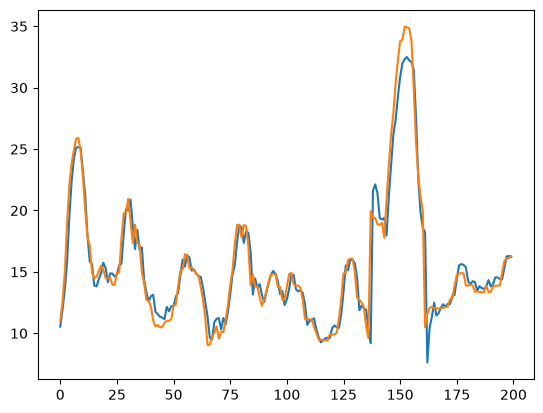

In [31]:
plt.plot(y_preds[:200])
plt.plot(ys[:200])